In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

df["Target"] = data.target
df["Diagnosis"] = df["Target"].map({0: "Malignant", 1: "Benign"})

print("Shape:", df.shape)
display(df.head())
print("\nTarget distribution:")
print(df["Diagnosis"].value_counts())

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant



Target distribution:
Diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


In [2]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nTarget %:")
print(df["Diagnosis"].value_counts(normalize=True).mul(100).round(2))

Shape: (569, 32)
Missing values: 0
Duplicate rows: 0

Target %:
Diagnosis
Benign       62.74
Malignant    37.26
Name: proportion, dtype: float64


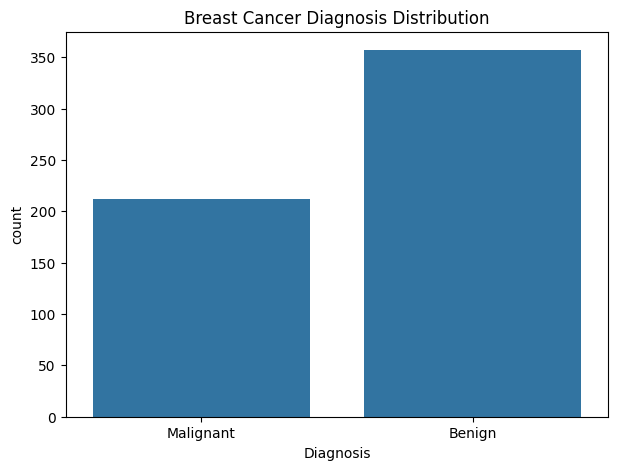

In [3]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Diagnosis")
plt.title("Breast Cancer Diagnosis Distribution")
plt.show()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity
Diagnosis,,,,,,,
Benign,12.147,17.915,78.075,462.790,0.092,0.080,0.046
Malignant,17.463,21.605,115.365,978.376,0.103,0.145,0.161


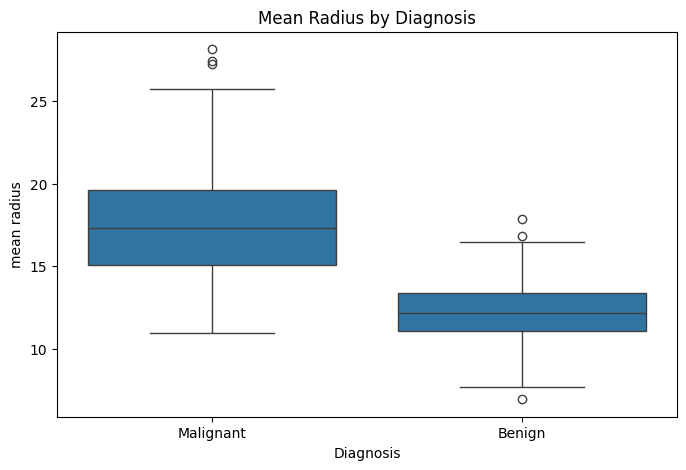

In [4]:
eda_features = ["mean radius", "mean texture", "mean perimeter", "mean area",
                 "mean smoothness", "mean compactness", "mean concavity"]

display(df.groupby("Diagnosis")[eda_features].mean().round(3))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Diagnosis", y="mean radius")
plt.title("Mean Radius by Diagnosis")
plt.show()

In [5]:
X = df.drop(columns=["Target", "Diagnosis"])
y = df["Target"]   # 0 = Malignant, 1 = Benign

print("X:", X.shape, "y:", y.shape)

X: (569, 30) y: (569,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

Train: 455 Test: 114


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)     # fit ONLY on train — no leakage
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [8]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=2000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [9]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=200, random_state=42)
random_forest_model.fit(X_train, y_train)   # tree-based — scaling not needed

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

def evaluate_model(name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)   # rows/cols ordered [0=Malignant, 1=Benign]
    malignant_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])

    print("=" * 60); print(name); print("=" * 60)
    print(f"Accuracy        : {accuracy:.3f}")
    print(f"Precision       : {precision:.3f}")
    print(f"Recall (Benign) : {recall:.3f}")
    print(f"F1 Score        : {f1:.3f}")
    print(f"ROC-AUC         : {roc_auc:.3f}")
    print(f"Malignant Recall: {malignant_recall:.3f}")
    print(classification_report(y_true, y_pred, target_names=["Malignant", "Benign"]))
    return [accuracy, precision, recall, f1, roc_auc, malignant_recall]

logistic_results = evaluate_model("LOGISTIC REGRESSION", y_test, logistic_pred, logistic_prob)
rf_results = evaluate_model("RANDOM FOREST", y_test, rf_pred, rf_prob)

LOGISTIC REGRESSION
Accuracy        : 0.982
Precision       : 0.986
Recall (Benign) : 0.986
F1 Score        : 0.986
ROC-AUC         : 0.995
Malignant Recall: 0.976
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RANDOM FOREST
Accuracy        : 0.956
Precision       : 0.959
Recall (Benign) : 0.972
F1 Score        : 0.966
ROC-AUC         : 0.993
Malignant Recall: 0.929
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
comparison = pd.DataFrame(
    [logistic_results, rf_results],
    columns=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Malignant Recall"],
    index=["Logistic Regression", "Random Forest"]
)
display(comparison.round(3))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Malignant Recall
Logistic Regression,0.982,0.986,0.986,0.986,0.995,0.976
Random Forest,0.956,0.959,0.972,0.966,0.993,0.929


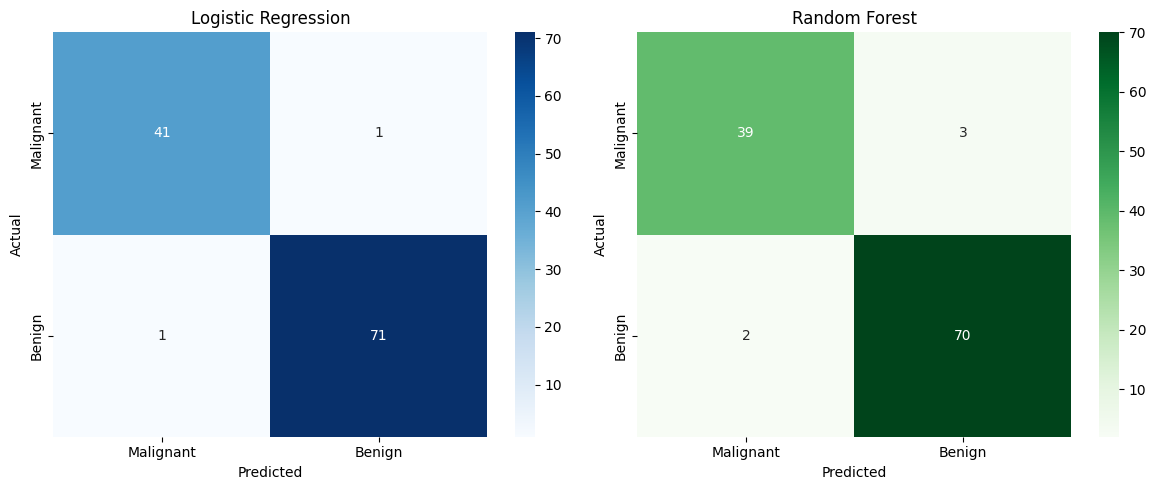

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, logistic_pred), annot=True, fmt="d", cmap="Blues",
            ax=axes[0], xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[0].set_title("Logistic Regression"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens",
            ax=axes[1], xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[1].set_title("Random Forest"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout(); plt.show()

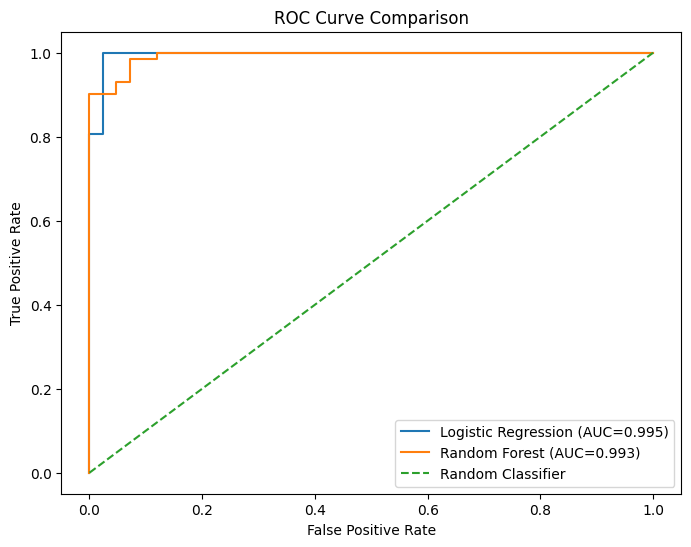

In [13]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistic, tpr_logistic, label=f"Logistic Regression (AUC={roc_auc_score(y_test, logistic_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison"); plt.legend(); plt.show()

,Feature,Importance
22,worst perimeter,0.1331
23,worst area,0.1281
27,worst concave points,0.1081
7,mean concave points,0.0944
20,worst radius,0.0906
0,mean radius,0.0587
2,mean perimeter,0.0552
3,mean area,0.0499
6,mean concavity,0.0462
26,worst concavity,0.0354


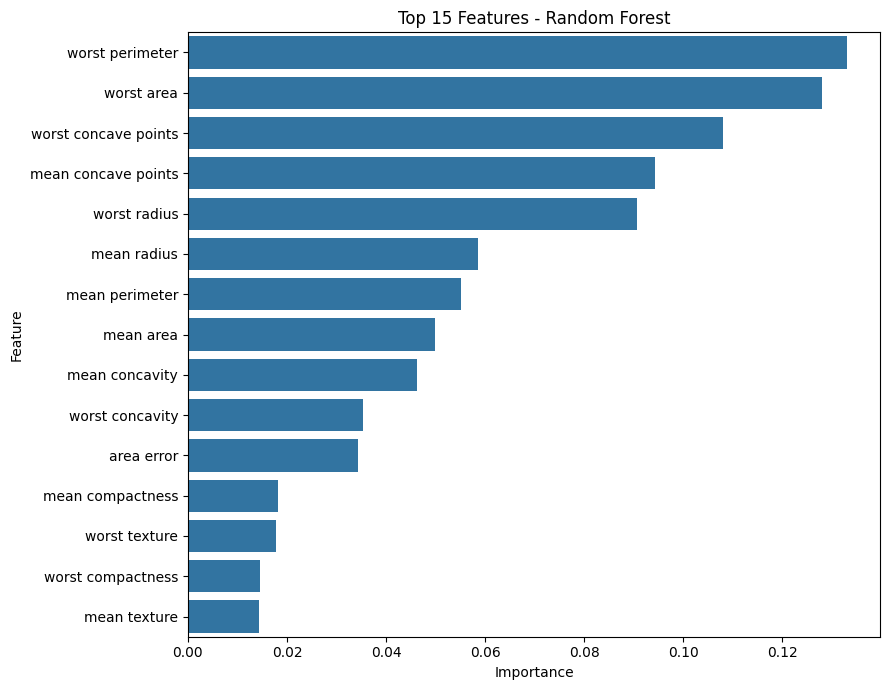

In [14]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance.head(15).round(4))

plt.figure(figsize=(9, 7))
sns.barplot(data=rf_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout(); plt.show()

In [15]:
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

# FIX: explicit Independent masker with full training set as background,
# avoids SHAP's default 100-sample random subsampling (which otherwise makes
# SHAP values slightly different every run — not reproducible).
masker = shap.maskers.Independent(X_train_scaled, max_samples=len(X_train_scaled))
explainer = shap.LinearExplainer(logistic_model, masker)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP shape:", shap_values.shape)

SHAP shape: (114, 30)


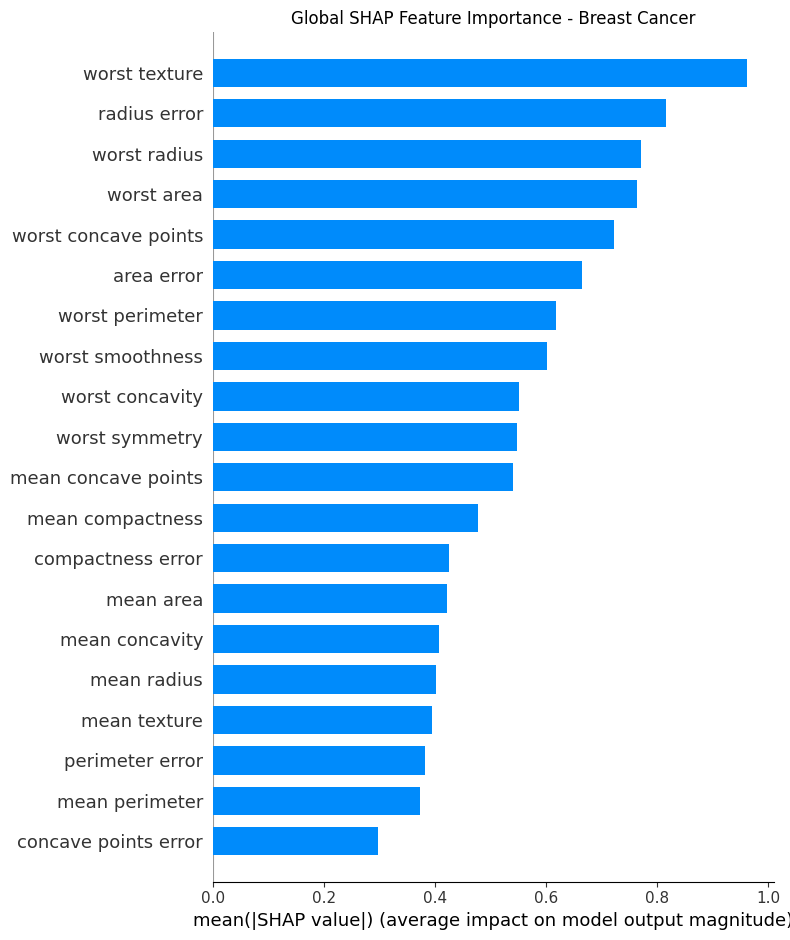

In [16]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Global SHAP Feature Importance - Breast Cancer")
plt.tight_layout(); plt.show()

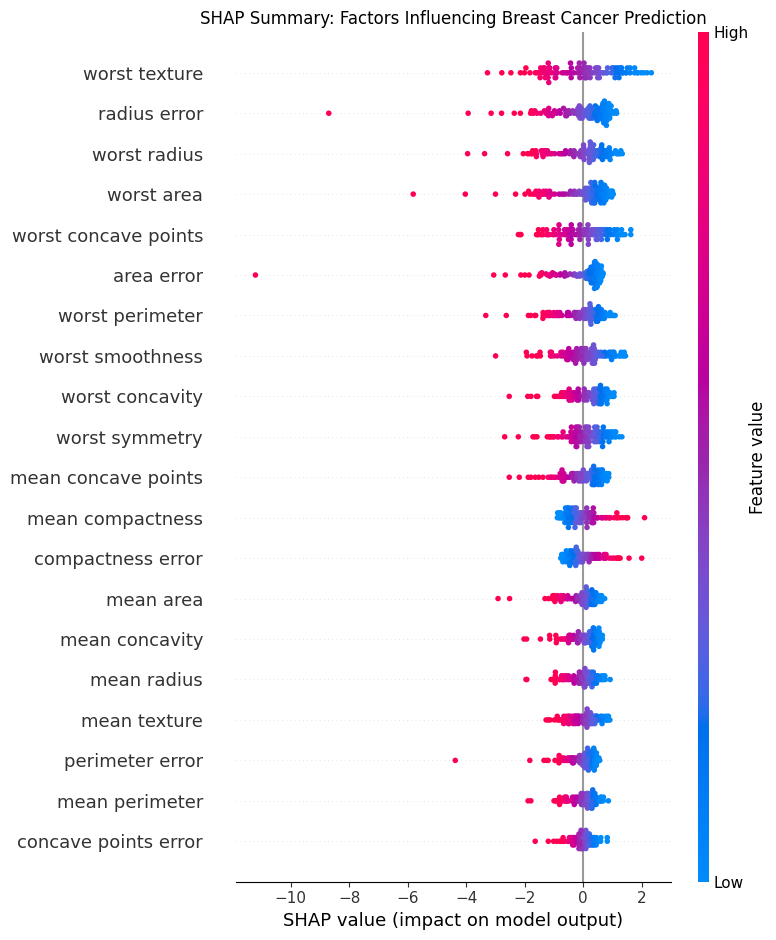

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("SHAP Summary: Factors Influencing Breast Cancer Prediction")
plt.tight_layout(); plt.show()

In [18]:
patient_index = 0
patient_data = X_test_scaled.iloc[[patient_index]]
patient_shap = shap_values[patient_index]

patient_prediction = logistic_model.predict(patient_data)[0]
patient_probability = logistic_model.predict_proba(patient_data)[0]

predicted_class = "Malignant" if patient_prediction == 0 else "Benign"
print("Predicted class:", predicted_class)
print(f"Malignant probability: {patient_probability[0]:.2%}")
print(f"Benign probability: {patient_probability[1]:.2%}")

individual_explanation = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "SHAP Value": patient_shap,
    "Feature Value": patient_data.iloc[0].values
})
individual_explanation["Absolute SHAP"] = individual_explanation["SHAP Value"].abs()
individual_explanation = individual_explanation.sort_values("Absolute SHAP", ascending=False)

display(individual_explanation[["Feature", "Feature Value", "SHAP Value"]].head(10).round(4))

Predicted class: Malignant
Malignant probability: 100.00%
Benign probability: 0.00%


,Feature,Feature Value,SHAP Value
21,worst texture,1.7082,-2.1440
23,worst area,1.9137,-1.8137
10,radius error,1.6582,-1.7958
20,worst radius,1.8622,-1.7646
22,worst perimeter,2.1706,-1.6567
13,area error,1.6098,-1.4957
5,mean compactness,1.9159,1.2422
12,perimeter error,2.1993,-1.1971
7,mean concave points,1.6989,-1.1963
1,mean texture,2.1640,-1.1960


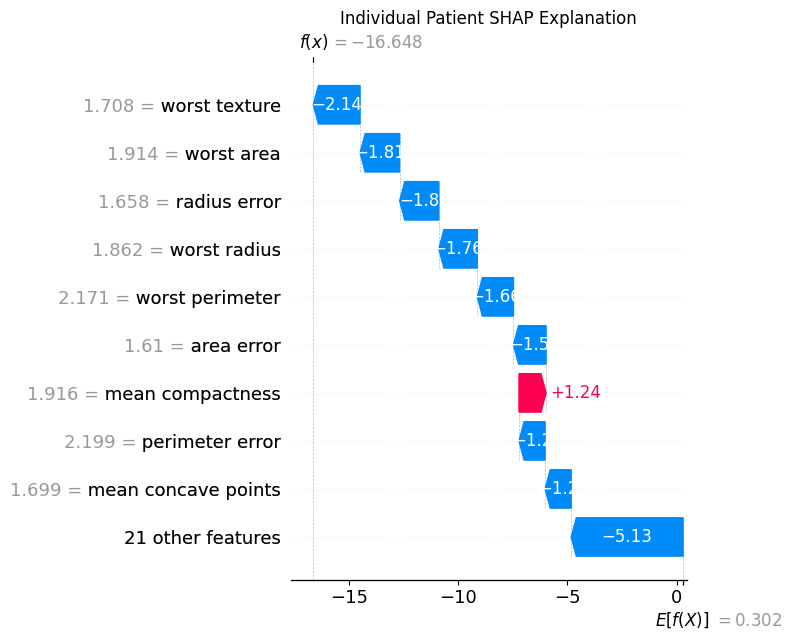

In [19]:
patient_explanation = shap.Explanation(
    values=patient_shap,
    base_values=explainer.expected_value,
    data=patient_data.iloc[0].values,
    feature_names=X_test_scaled.columns
)

shap.plots.waterfall(patient_explanation, max_display=10, show=False)
plt.title("Individual Patient SHAP Explanation")
plt.tight_layout(); plt.show()

In [21]:
print("=" * 70); print("FINAL PROJECT SUMMARY"); print("=" * 70)
print("\nDataset: Wisconsin Diagnostic Breast Cancer (WDBC)")
print("Samples:", len(df), "| Features:", X.shape[1])

best_model = comparison["ROC-AUC"].idxmax()
print(f"\nBest model (ROC-AUC): {best_model} ({comparison['ROC-AUC'].max():.3f})")

best_malignant = comparison["Malignant Recall"].idxmax()
print(f"Highest Malignant Recall: {best_malignant} ({comparison['Malignant Recall'].max():.3f})")


FINAL PROJECT SUMMARY

Dataset: Wisconsin Diagnostic Breast Cancer (WDBC)
Samples: 569 | Features: 30

Best model (ROC-AUC): Logistic Regression (0.995)
Highest Malignant Recall: Logistic Regression (0.976)
